# Setup

## Imports

In [1]:
import sys
import os

import torch

sys.path.append(os.path.abspath("../src"))

from models import ResNet18, DenseNet121, EfficientNetB0, MobileNetV2, ShuffleNetV2, SqueezeNet, VGG11, GoogLeNet

from data import (
    prepare_full_dataframe, 
    prepare_data
 )

from utils import (
    get_device,
    load_experiment_outputs,
    save_experiment_outputs,
    get_experiment_outputs_path
 )

from train import run_training_pipeline, run_smoke_test

from experiement_types import Metrics, History, ModelOutput

import config

In [2]:
import sys
print(f"Python executable: {sys.executable}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Python executable: c:\Users\profb\PROJECTS\cxr-model-benchmark\.venv\Scripts\python.exe
PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 5090 Laptop GPU


## Data Preprocessing

In [3]:
dataset_path = config.DATASET_PATH
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())
df["Finding Labels"].value_counts().head()

Dataset location: C:\Users\profb\PROJECTS\datasets\NIH_Chest_X-Rays
Total images: 112120
Unique patients: 30805


Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64

In [4]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [5]:
train_loader, val_loader, test_loader = prepare_data(df)
device = get_device()

Using CUDA (GPU)


## Training Set Up

In [6]:
model_registry = {
    "DenseNet121": lambda: DenseNet121(num_classes=2, in_channels=1),
    "EfficientNet-B0": lambda: EfficientNetB0(num_classes=2, in_channels=1),
    "GoogLeNet": lambda: GoogLeNet(num_classes=2, in_channels=1),
    "ResNet18": lambda: ResNet18(num_classes=2, in_channels=1),
    "VGG11": lambda: VGG11(num_classes=2, in_channels=1),
    "MobileNetV2": lambda: MobileNetV2(num_classes=2, in_channels=1),
    "ShuffleNetV2": lambda: ShuffleNetV2(num_classes=2, in_channels=1),
    "SqueezeNet": lambda: SqueezeNet(num_classes=2, in_channels=1),
}
model_names = list(model_registry.keys())
model_builders = list(model_registry.values())

experiment_outputs_path = get_experiment_outputs_path()
experiment_outputs = load_experiment_outputs(experiment_outputs_path)
print(f"Loaded {len(experiment_outputs)} saved result(s) from {experiment_outputs_path}")

def _print_training_summary(metrics, history):
    print("\n=== Training Summary ===")
    print(f"Model: {metrics['model']}")
    print(f"Epochs: {metrics['epochs']}")
    print(
        "Test Metrics -> "
        f"Loss: {metrics['test_loss']:.4f}, "
        f"Acc: {metrics['accuracy']:.4f}, "
        f"Precision: {metrics['precision']:.4f}, "
        f"Recall: {metrics['recall']:.4f}, "
        f"F1: {metrics['f1']:.4f}, "
        f"AUPRC: {metrics['auprc']:.4f}"
    )
    best_epoch = history.get("best_epoch")
    if best_epoch is not None:
        print(f"Best Epoch: {best_epoch}")
    lr_backbone = history.get("lr_backbone", [])
    lr_head = history.get("lr_head", [])
    if lr_backbone or lr_head:
        if lr_backbone:
            print(f"Backbone LR (last): {lr_backbone[-1]:.6g}")
        if lr_head:
            print(f"Head LR (last): {lr_head[-1]:.6g}")
    elif history.get("lr"):
        print(f"LR (last): {history['lr'][-1]:.6g}")

def train_and_store_model(index, live_plot=True, return_output=False):
    metrics, history = run_training_pipeline(
        model_names[index],
        model_builders[index],
        train_loader,
        val_loader,
        test_loader,
        device,
        live_plot=live_plot,
    )
    model_output = ModelOutput(
        metrics=Metrics(**metrics),
        history=History(**history),
    )
    experiment_outputs[model_names[index]] = model_output
    save_experiment_outputs(experiment_outputs, experiment_outputs_path)

    print(f"Saved {model_names[index]} results to {experiment_outputs_path}")
    _print_training_summary(metrics, history)

    if return_output:
        return model_output
    return None

Loaded 5 saved result(s) from c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\experiment_outputs\experiment_outputs.json


# Model Individual Training/Testing

## Heavy Pretrained Family
DenseNet121, EfficientNet-B0, GoogLeNet

### DenseNet-121

#### Smoke Test

In [ ]:
run_smoke_test(
    model_name=model_names[0],
    model_builder=model_builders[0],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[0]}-SMOKE",
)

#### Training

In [ ]:
train_and_store_model(0, live_plot=True)

### EfficientNet-B0

#### Smoke Test

In [ ]:
run_smoke_test(
    model_name=model_names[1],
    model_builder=model_builders[1],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[1]}-SMOKE",
)

#### Training

In [ ]:
train_and_store_model(1, live_plot=True)

### GoogLeNet

#### Smoke Test

In [7]:
run_smoke_test(
    model_name=model_names[2],
    model_builder=model_builders[2],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[2]}-SMOKE",
)


=== Smoke test: DenseNet121 (epochs=1, patience=1) ===

=== Training DenseNet121 ===
Starting fresh training (resume disabled): c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\checkpoints\best_densenet121\latest.pt
AMP enabled (bf16, grad scaler: off)
channels_last enabled
Scheduler active: type=warmup_cosine, start_epoch=1, steps_per_epoch=1, cosine_t_max=0


Train Epoch 1:   0%|          | 0/309 [00:15<?, ?it/s]

  VRAM a/r/p: 0.06G(0.3%)/2.47G(10.3%)/1.67G(7.0%)


Val Epoch 1:   0%|          | 0/66 [00:15<?, ?it/s]

Epoch 1/1 | ETA (Remaining): 00:00:00 | Total ETA: 00:02:30
  Train Loss: 0.6561 | Train Acc: 0.6156
  Val Loss: 0.6396 | Val Acc: 0.6460
  Val Precision: 0.6187
  Val Recall: 0.5830 | Val F1: 0.6003
  Val AUPRC: 0.6262
  Head LR: 1e-06
  Optimizer: AdamW | Weight Decay: 5e-05 | No-Decay Groups: 1
------------------------------------------------------------
Saved best model to c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\models\best_densenet121.pt
------------------------------------------------------------


Val:   0%|          | 0/64 [00:15<?, ?it/s]

Smoke test persistence verified for 'DenseNet121-SMOKE' at c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\experiment_outputs\experiment_outputs.json


({'model': 'DenseNet121',
  'epochs': 1,
  'batch_size': 256,
  'image_size': 256,
  'test_loss': 0.6335601773315811,
  'accuracy': 0.6540583619421285,
  'precision': 0.6321518280770304,
  'recall': 0.6010348945203662,
  'f1': 0.6162007753519689,
  'auprc': 0.6486366838977377},
 {'train_loss': [0.6561149782975825],
  'train_acc': [0.615640915194973],
  'val_loss': [0.639567616399295],
  'val_acc': [0.6459642052862392],
  'val_precision': [0.6187258687258688],
  'val_recall': [0.5830301455301455],
  'val_f1': [0.6003478726251004],
  'val_auprc': [0.6262392364220966],
  'lr': [1e-06],
  'lr_backbone': [],
  'lr_head': [1e-06],
  'backbone_frozen': [True],
  'vram_peak_pct': [6.9831595345949555],
  'best_epoch': 1})

#### Training

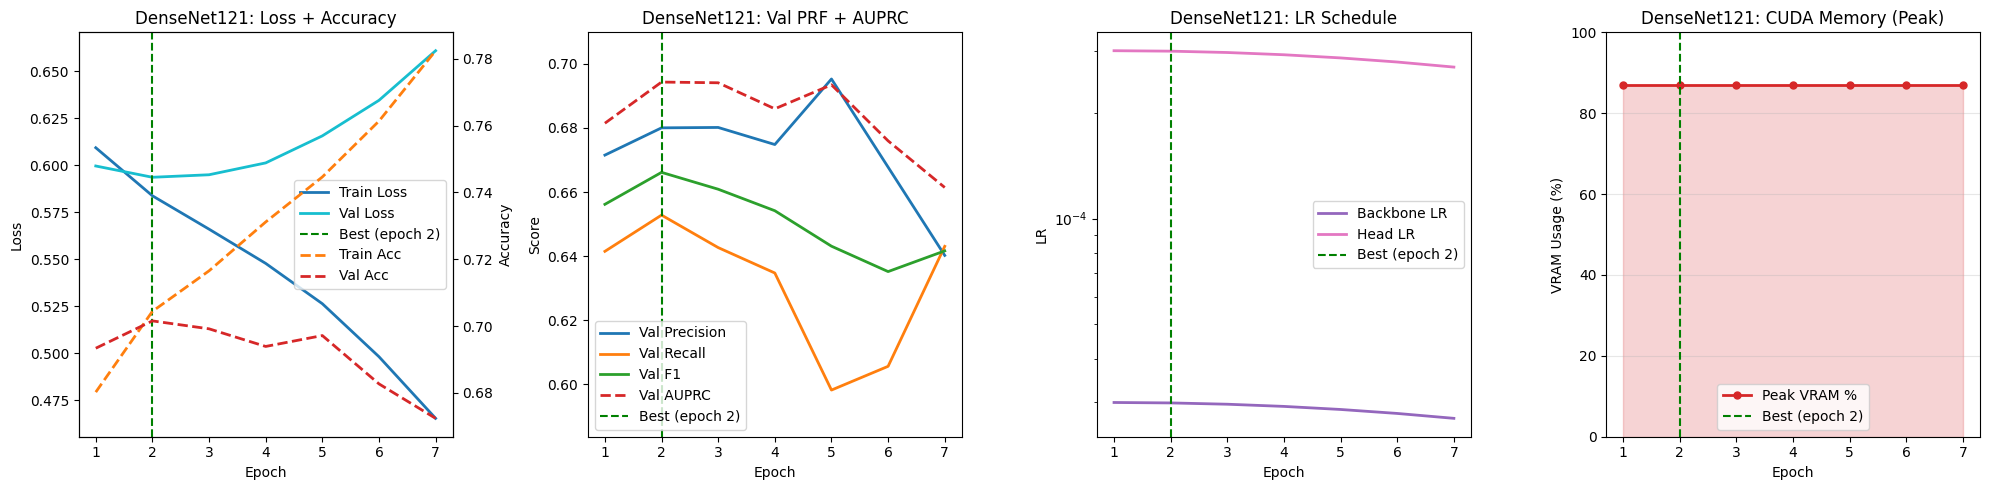

Train Epoch 8:   0%|          | 0/309 [00:00<?, ?it/s]

  VRAM a/r/p: 0.19G(0.8%)/22.66G(94.9%)/20.78G(87.0%)


Val Epoch 8:   0%|          | 0/66 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [8]:
train_and_store_model(2, live_plot=True)

## Midweight Pretrained Family
ResNet18, VGG11

### ResNet-18

#### Smoke Test

In [ ]:
run_smoke_test(
    model_name=model_names[3],
    model_builder=model_builders[3],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[3]}-SMOKE",
)

#### Training

In [ ]:
train_and_store_model(3, live_plot=True)

### VGG11

#### Smoke Test

In [ ]:
run_smoke_test(
    model_name=model_names[4],
    model_builder=model_builders[4],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[4]}-SMOKE",
)

#### Training

In [ ]:
train_and_store_model(4, live_plot=True)

## Lightweight Pretrained Family
MobileNetV2, ShuffleNetV2, SqueezeNet

### MobileNet-V2

#### Smoke Test

In [ ]:
run_smoke_test(
    model_name=model_names[5],
    model_builder=model_builders[5],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[5]}-SMOKE",
)

#### Training

In [ ]:
train_and_store_model(5, live_plot=True)

### ShuffleNetV2

#### Smoke Test

In [ ]:
run_smoke_test(
    model_name=model_names[6],
    model_builder=model_builders[6],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[6]}-SMOKE",
)

#### Training

In [ ]:
train_and_store_model(6, live_plot=True)

### SqueezeNet

#### Smoke Test

In [ ]:
run_smoke_test(
    model_name=model_names[7],
    model_builder=model_builders[7],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[7]}-SMOKE",
)

#### Training

In [ ]:
train_and_store_model(7, live_plot=True)

# Model Comparison Plots
Visualize the test results for all models using bar plots for accuracy, precision, recall, and F1 score.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

experiment_outputs = load_experiment_outputs(experiment_outputs_path)
if not experiment_outputs:
    raise ValueError(
        f"No saved experiment outputs found at {experiment_outputs_path}. Run at least one training cell first."
    )

results_df = pd.DataFrame([
    vars(out.metrics) for out in experiment_outputs.values()
])

metrics = ["accuracy", "precision", "recall", "f1", "auprc"]

plt.figure(figsize=(12, 6))
results_melted = results_df.melt(
    id_vars="model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
 )

sns.barplot(
    data=results_melted,
    x="model",
    y="Score",
    hue="Metric",
    errorbar=None,
)

plt.title("Model Comparison on Test Set")
plt.ylabel("Score")

min_score = results_melted["Score"].min()
max_score = results_melted["Score"].max()
padding = max(0.01, 0.08 * (max_score - min_score))
ymin = max(0.0, min_score - padding)
ymax = min(1.0, max_score + padding)
plt.ylim(ymin, ymax)

plt.legend(loc="lower right")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()